# TTC Delays Prediction with Prophet

## 1. Import all libraries required

In [1]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

## 2. Read 2024 dataset and assign to new table the date and minute delays

In [2]:
delays_2024 = pd.read_excel("ttc-streetcar-delay-data-2024.xlsx")  

In [3]:
df = delays_2024[["Date", "Min Delay"]]

## 3. Prepare the dataset

In [4]:
# Convert to datetime
df = df.copy()
df['Date'] = pd.to_datetime(df['Date'])

# Aggregate (since you have multiple records per date)
daily = df.groupby('Date')['Min Delay'].mean().reset_index()

# Rename columns for Prophet
daily = daily.rename(columns={'Date': 'ds', 'Min Delay': 'y'})

## 4. Create the Prophet model

In [5]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='additive'
)

model.fit(daily)

15:44:26 - cmdstanpy - INFO - Chain [1] start processing
15:44:26 - cmdstanpy - INFO - Chain [1] done processing


## 5. Create future dataframe

In [6]:
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

## 6. Plot the predictions

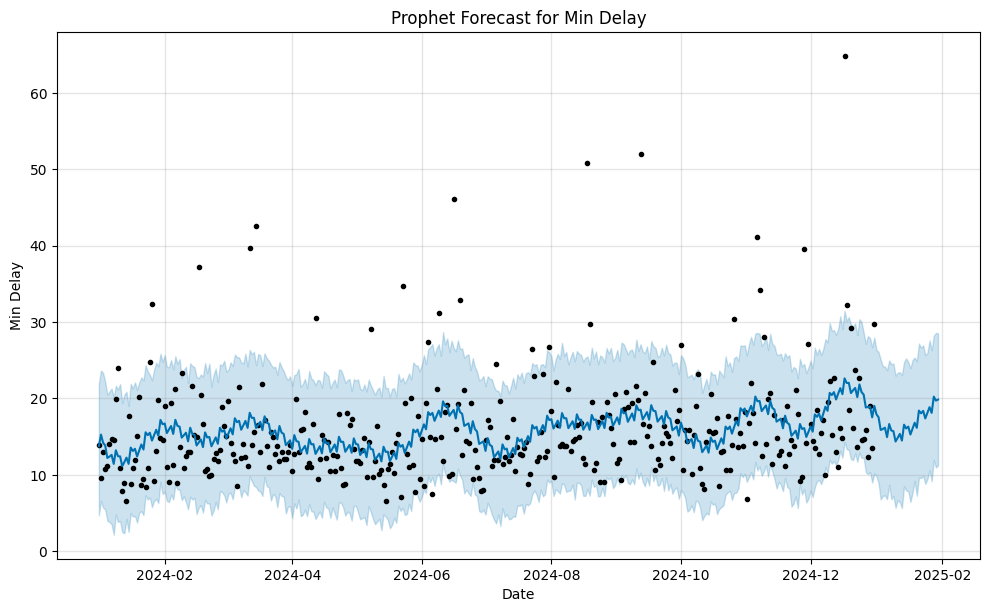

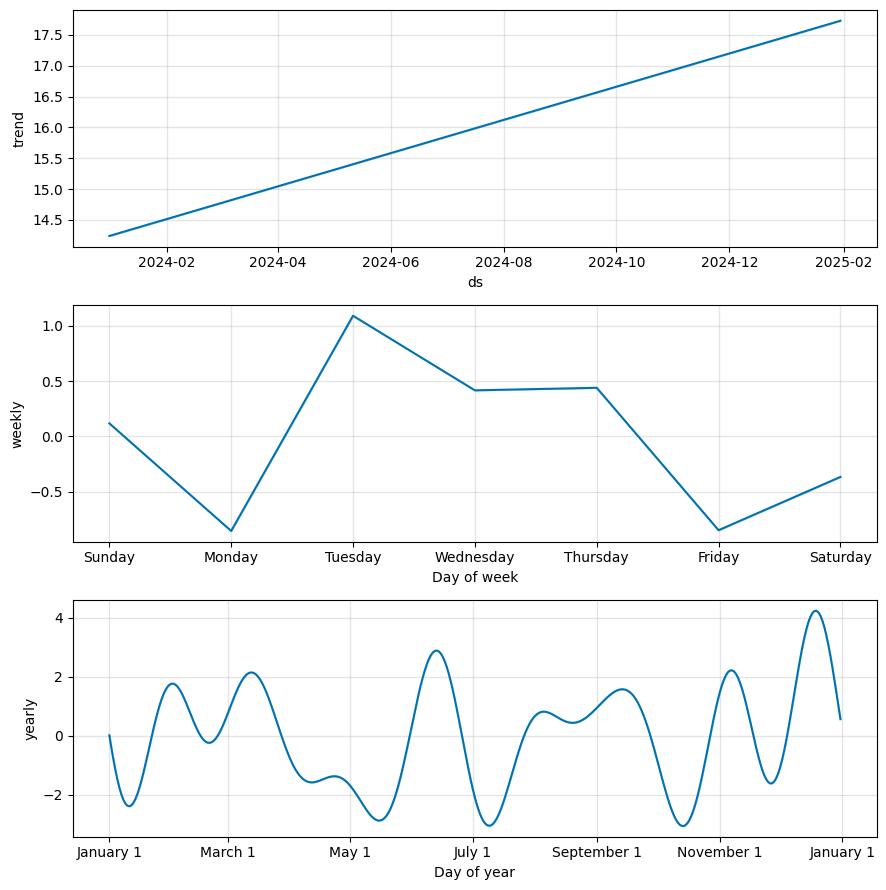

In [7]:
# Forecast plot
model.plot(forecast)
plt.title("Prophet Forecast for Min Delay")
plt.xlabel("Date")
plt.ylabel("Min Delay")
plt.show()

# Components plot (trend, weekly, yearly)
model.plot_components(forecast)
plt.show()

In [8]:
# Merge actual and predicted
merged = daily.merge(forecast[['ds', 'yhat']], on='ds', how='left')
print(merged.tail(10))

            ds          y       yhat
356 2024-12-22  23.673913  21.354647
357 2024-12-23  13.583333  20.153239
358 2024-12-24  22.636364  21.815422
359 2024-12-25  14.594595  20.817733
360 2024-12-26  14.611111  20.477615
361 2024-12-27  15.868421  18.798452
362 2024-12-28  12.250000  18.862197
363 2024-12-29  19.000000  18.913650
364 2024-12-30  13.516129  17.503295
365 2024-12-31  29.688889  19.008247


In [9]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(7)

,ds,yhat,yhat_lower,yhat_upper
389,2025-01-24,17.359747,8.784513,25.635788
390,2025-01-25,18.111492,9.409947,25.940813
391,2025-01-26,18.841736,10.587124,27.583816
392,2025-01-27,18.088405,9.138362,26.298848
393,2025-01-28,20.216803,11.920941,28.188149
394,2025-01-29,19.695400,10.950062,28.561005
395,2025-01-30,19.833584,11.199420,28.508955


In [10]:
# result: 
#forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv('prophet_forecast.csv', index=False)